# Análisis de Churn — PlayOn+ (servicio de streaming ficticio)

**Objetivo:** identificar las causas raíz del abandono de suscriptores y proponer
estrategias de retención basadas en datos.

Fuente de datos: `data/churn_streaming.db` (SQLite), generada de forma sintética
para este proyecto de portfolio, simulando 1.200 clientes y 18 meses de actividad.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

conn = sqlite3.connect("../data/churn_streaming.db")

clientes = pd.read_sql_query("SELECT * FROM Clientes", conn)
actividad = pd.read_sql_query("SELECT * FROM Actividad", conn)
actividad["Fecha_Mes"] = pd.to_datetime(actividad["Fecha_Mes"])

print(f"Clientes: {len(clientes):,}")
print(f"Registros de actividad: {len(actividad):,}")
clientes.head()

Clientes: 1,200
Registros de actividad: 6,105


,ID_Cliente,Nombre,Fecha_Alta,Edad,Ciudad,Metodo_Pago
0,1,Nicolás López,2025-04-01,36,Buenos Aires,Tarjeta de Débito
1,2,Emma Martínez,2025-10-01,30,Córdoba,Tarjeta de Débito
2,3,Agustín Ramírez,2025-05-01,38,Buenos Aires,Tarjeta de Crédito
3,4,Emma Benítez,2025-06-01,47,Neuquén,Tarjeta de Crédito
4,5,Ignacio Medina,2025-03-01,29,Mar del Plata,Tarjeta de Crédito


## 1. Tasa de Churn Mensual

Evolución de la tasa de baja mes a mes (clientes que cancelaron / clientes activos ese mes).

In [2]:
query_churn_mensual = '''
WITH activos_inicio_mes AS (
    SELECT Fecha_Mes, COUNT(*) AS total_activos
    FROM Actividad GROUP BY Fecha_Mes
),
bajas_mes AS (
    SELECT Fecha_Mes, SUM(CASE WHEN Suscripcion_Activa = 0 THEN 1 ELSE 0 END) AS bajas
    FROM Actividad GROUP BY Fecha_Mes
)
SELECT a.Fecha_Mes, a.total_activos, b.bajas,
       ROUND(100.0 * b.bajas / a.total_activos, 2) AS tasa_churn_pct
FROM activos_inicio_mes a
JOIN bajas_mes b ON a.Fecha_Mes = b.Fecha_Mes
ORDER BY a.Fecha_Mes;
'''

churn_mensual = pd.read_sql_query(query_churn_mensual, conn, parse_dates=["Fecha_Mes"])
churn_mensual

,Fecha_Mes,total_activos,bajas,tasa_churn_pct
0,2024-07-01,39,2,5.13
1,2024-08-01,103,7,6.80
2,2024-09-01,162,21,12.96
3,2024-10-01,219,24,10.96
4,2024-11-01,254,31,12.20
5,2024-12-01,292,45,15.41
6,2025-01-01,317,45,14.20
7,2025-02-01,348,45,12.93
8,2025-03-01,362,48,13.26
9,2025-04-01,384,46,11.98


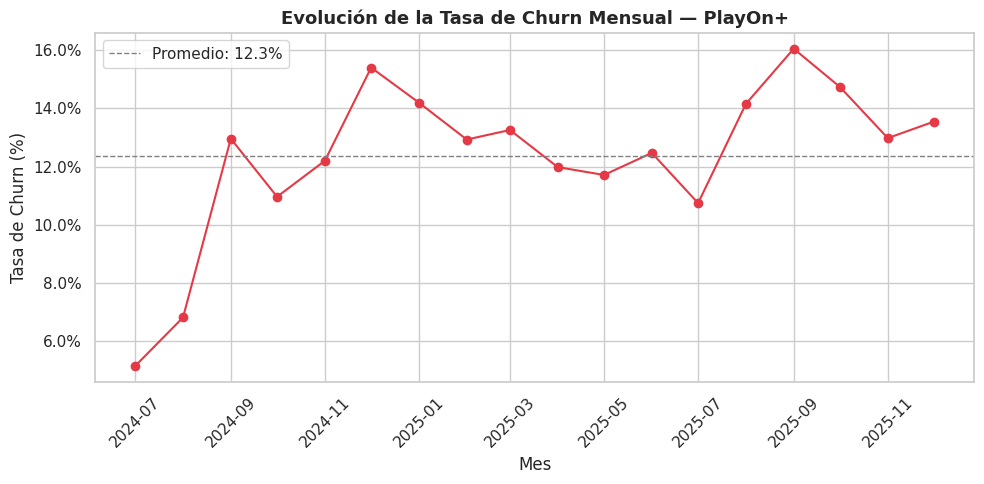

In [3]:
fig, ax = plt.subplots()
ax.plot(churn_mensual["Fecha_Mes"], churn_mensual["tasa_churn_pct"], marker="o", color="#E63946")
ax.set_title("Evolución de la Tasa de Churn Mensual — PlayOn+", fontsize=13, weight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Tasa de Churn (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(churn_mensual["tasa_churn_pct"].mean(), color="gray", linestyle="--", linewidth=1,
           label=f'Promedio: {churn_mensual["tasa_churn_pct"].mean():.1f}%')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("churn_mensual.png", dpi=150)
plt.show()

## 2. Churn por antigüedad del cliente

¿En qué mes de contrato se produce la mayor fuga? Esto ayuda a saber si el problema
es el fin de una promoción, un problema de onboarding, o desgaste a largo plazo.

In [4]:
query_antiguedad = '''
WITH actividad_con_antiguedad AS (
    SELECT a.ID_Cliente, a.Fecha_Mes, a.Suscripcion_Activa,
        CAST((STRFTIME('%Y', a.Fecha_Mes) - STRFTIME('%Y', c.Fecha_Alta)) * 12 +
             (STRFTIME('%m', a.Fecha_Mes) - STRFTIME('%m', c.Fecha_Alta)) AS INTEGER) AS antiguedad_meses
    FROM Actividad a JOIN Clientes c ON c.ID_Cliente = a.ID_Cliente
)
SELECT antiguedad_meses, COUNT(*) AS total_registros,
       SUM(CASE WHEN Suscripcion_Activa = 0 THEN 1 ELSE 0 END) AS bajas,
       ROUND(100.0 * SUM(CASE WHEN Suscripcion_Activa = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS tasa_churn_pct
FROM actividad_con_antiguedad
GROUP BY antiguedad_meses
ORDER BY antiguedad_meses;
'''

churn_antiguedad = pd.read_sql_query(query_antiguedad, conn)
churn_antiguedad.head(12)

,antiguedad_meses,total_registros,bajas,tasa_churn_pct
0,0,1200,77,6.42
1,1,1069,74,6.92
2,2,934,247,26.45
3,3,635,71,11.18
4,4,529,72,13.61
5,5,421,58,13.78
6,6,335,47,14.03
7,7,263,38,14.45
8,8,206,29,14.08
9,9,157,31,19.75


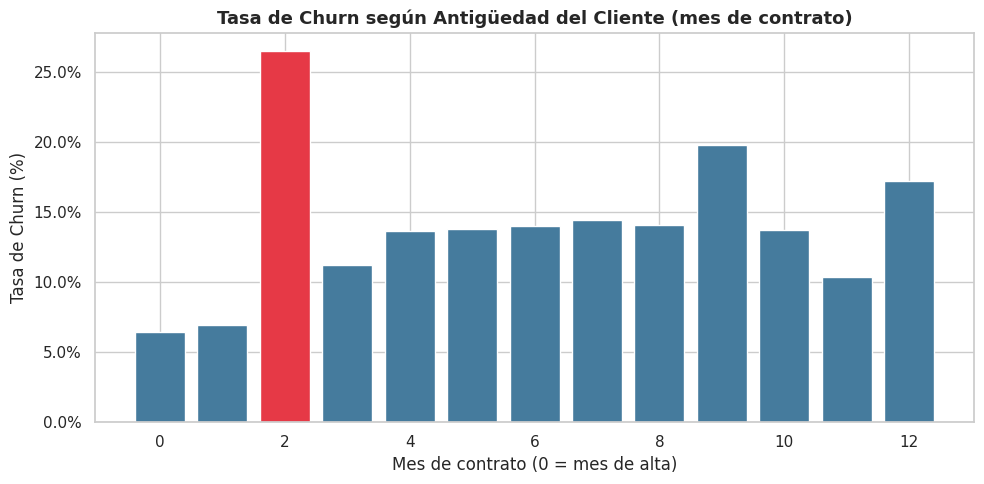

Pico de churn: mes 2 de contrato, con 26.45% de bajas


In [5]:
fig, ax = plt.subplots()
datos = churn_antiguedad[churn_antiguedad["antiguedad_meses"] <= 12]
colores = ["#E63946" if m == datos.loc[datos["tasa_churn_pct"].idxmax(), "antiguedad_meses"]
           else "#457B9D" for m in datos["antiguedad_meses"]]
ax.bar(datos["antiguedad_meses"], datos["tasa_churn_pct"], color=colores)
ax.set_title("Tasa de Churn según Antigüedad del Cliente (mes de contrato)", fontsize=13, weight="bold")
ax.set_xlabel("Mes de contrato (0 = mes de alta)")
ax.set_ylabel("Tasa de Churn (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig("churn_antiguedad.png", dpi=150)
plt.show()

pico = datos.loc[datos["tasa_churn_pct"].idxmax()]
print(f"Pico de churn: mes {int(pico['antiguedad_meses'])} de contrato, con {pico['tasa_churn_pct']}% de bajas")

## 3. Segmentación RFM (Recencia, Frecuencia, Valor de uso)

In [6]:
query_rfm = '''
WITH ultima_fecha AS (SELECT MAX(Fecha_Mes) AS fecha_max FROM Actividad),
metricas_cliente AS (
    SELECT ac.ID_Cliente, MAX(ac.Fecha_Mes) AS ultima_actividad,
        COUNT(*) AS meses_activos, ROUND(AVG(ac.Uso_Del_Servicio), 1) AS uso_promedio,
        MIN(ac.Suscripcion_Activa) AS tuvo_baja
    FROM Actividad ac GROUP BY ac.ID_Cliente
)
SELECT m.ID_Cliente, c.Nombre, m.ultima_actividad, m.meses_activos, m.uso_promedio,
    CASE
        WHEN m.tuvo_baja = 0 THEN 'Perdido'
        WHEN m.uso_promedio >= 15 AND m.meses_activos >= 3 THEN 'Campeón'
        WHEN m.uso_promedio < 10 OR m.meses_activos <= 2 THEN 'En riesgo'
        ELSE 'Regular'
    END AS segmento_rfm
FROM metricas_cliente m JOIN Clientes c ON c.ID_Cliente = m.ID_Cliente
ORDER BY segmento_rfm, m.uso_promedio DESC;
'''

rfm = pd.read_sql_query(query_rfm, conn)
segmentos = rfm["segmento_rfm"].value_counts()
segmentos

segmento_rfm
Perdido      798
Campeón      198
En riesgo    143
Regular       61
Name: count, dtype: int64

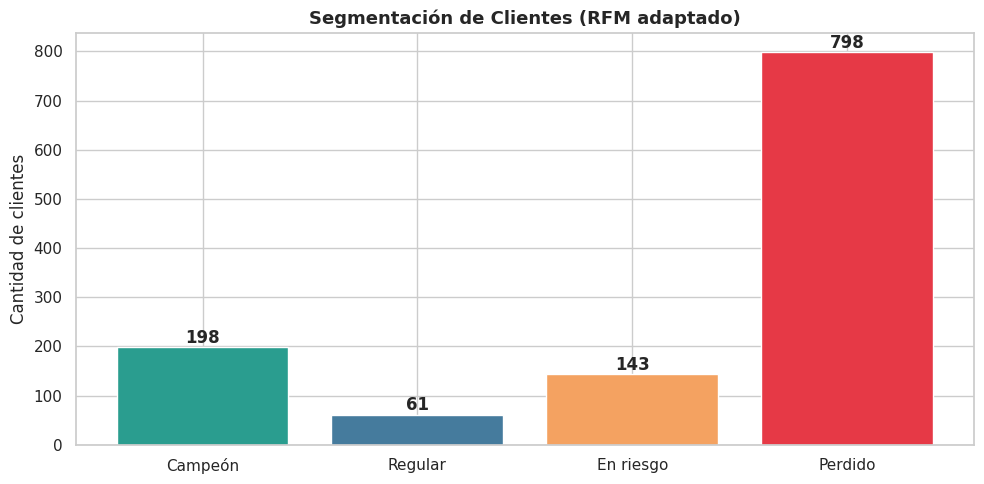

In [7]:
colores_segmento = {"Campeón": "#2A9D8F", "Regular": "#457B9D", "En riesgo": "#F4A261", "Perdido": "#E63946"}
fig, ax = plt.subplots()
segmentos_ordenados = segmentos.reindex(["Campeón", "Regular", "En riesgo", "Perdido"])
ax.bar(segmentos_ordenados.index, segmentos_ordenados.values,
       color=[colores_segmento[s] for s in segmentos_ordenados.index])
ax.set_title("Segmentación de Clientes (RFM adaptado)", fontsize=13, weight="bold")
ax.set_ylabel("Cantidad de clientes")
for i, v in enumerate(segmentos_ordenados.values):
    ax.text(i, v + 10, str(v), ha="center", weight="bold")
plt.tight_layout()
plt.savefig("segmentos_rfm.png", dpi=150)
plt.show()

## 4. Soporte técnico vs. Churn

¿Los clientes que más llaman a soporte cancelan con más frecuencia?

In [8]:
query_soporte = '''
WITH soporte_acumulado AS (
    SELECT ID_Cliente, SUM(Interacciones_Soporte) AS total_soporte, MIN(Suscripcion_Activa) AS tuvo_baja
    FROM Actividad GROUP BY ID_Cliente
)
SELECT
    CASE WHEN total_soporte = 0 THEN '0 llamados'
         WHEN total_soporte <= 2 THEN '1-2 llamados'
         ELSE 'Más de 2 llamados' END AS rango_soporte,
    COUNT(*) AS clientes,
    SUM(CASE WHEN tuvo_baja = 0 THEN 1 ELSE 0 END) AS clientes_que_cancelaron,
    ROUND(100.0 * SUM(CASE WHEN tuvo_baja = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS tasa_baja_pct
FROM soporte_acumulado GROUP BY rango_soporte ORDER BY tasa_baja_pct DESC;
'''

soporte = pd.read_sql_query(query_soporte, conn)
soporte

,rango_soporte,clientes,clientes_que_cancelaron,tasa_baja_pct
0,Más de 2 llamados,428,332,77.57
1,1-2 llamados,517,327,63.25
2,0 llamados,255,139,54.51


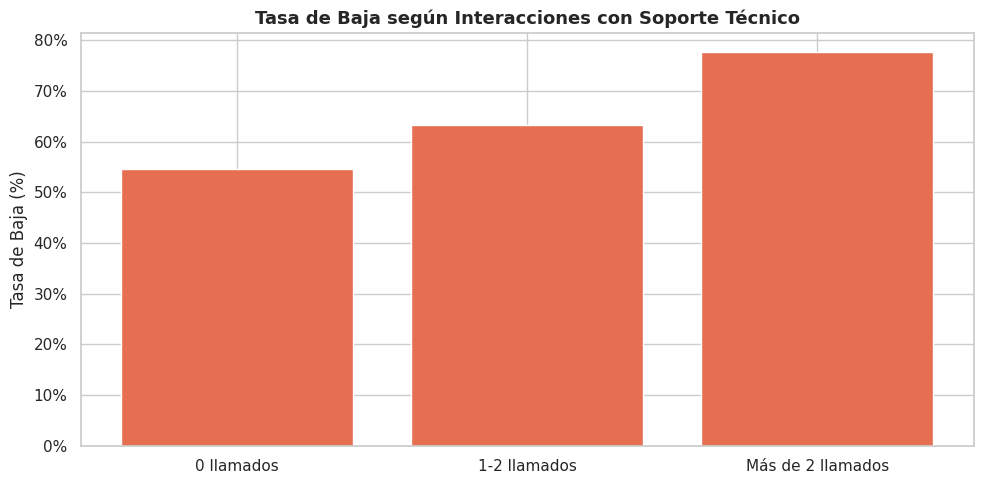

In [9]:
orden = ["0 llamados", "1-2 llamados", "Más de 2 llamados"]
soporte_o = soporte.set_index("rango_soporte").reindex(orden).reset_index()

fig, ax = plt.subplots()
ax.bar(soporte_o["rango_soporte"], soporte_o["tasa_baja_pct"], color="#E76F51")
ax.set_title("Tasa de Baja según Interacciones con Soporte Técnico", fontsize=13, weight="bold")
ax.set_ylabel("Tasa de Baja (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig("soporte_vs_churn.png", dpi=150)
plt.show()

## 5. Churn por Método de Pago

El churn por tarjeta de débito suele ser más "involuntario" (rechazos de cobro).

In [10]:
query_pago = '''
WITH estado_final_cliente AS (
    SELECT ID_Cliente, MIN(Suscripcion_Activa) AS tuvo_baja FROM Actividad GROUP BY ID_Cliente
)
SELECT c.Metodo_Pago, COUNT(*) AS total_clientes,
    SUM(CASE WHEN e.tuvo_baja = 0 THEN 1 ELSE 0 END) AS clientes_que_cancelaron,
    ROUND(100.0 * SUM(CASE WHEN e.tuvo_baja = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS tasa_churn_pct
FROM Clientes c JOIN estado_final_cliente e ON e.ID_Cliente = c.ID_Cliente
GROUP BY c.Metodo_Pago ORDER BY tasa_churn_pct DESC;
'''

pago = pd.read_sql_query(query_pago, conn)
pago

,Metodo_Pago,total_clientes,clientes_que_cancelaron,tasa_churn_pct
0,Tarjeta de Débito,342,265,77.49
1,Tarjeta de Crédito,561,361,64.35
2,Mercado Pago,232,135,58.19
3,Transferencia Bancaria,65,37,56.92


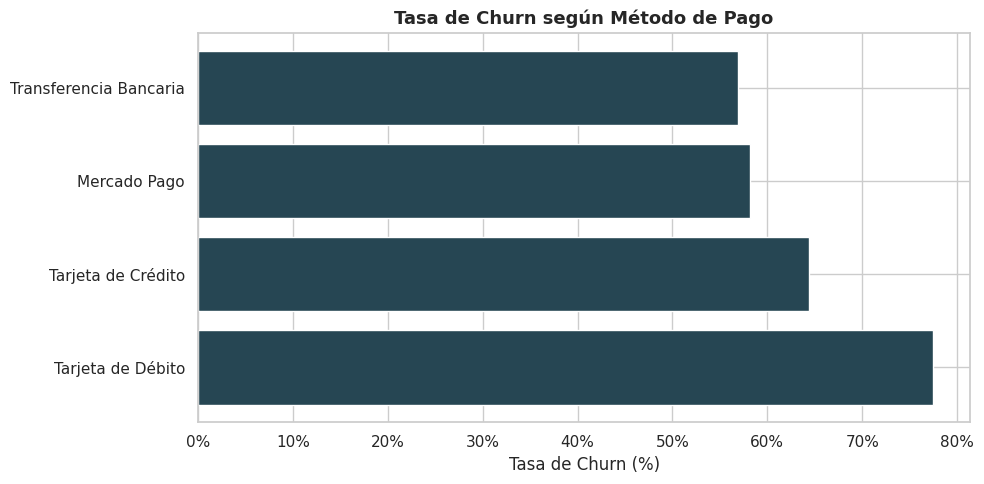

In [11]:
fig, ax = plt.subplots()
ax.barh(pago["Metodo_Pago"], pago["tasa_churn_pct"], color="#264653")
ax.set_title("Tasa de Churn según Método de Pago", fontsize=13, weight="bold")
ax.set_xlabel("Tasa de Churn (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig("churn_metodo_pago.png", dpi=150)
plt.show()

## 6. KPIs para el dashboard

Resumen ejecutivo con los indicadores clave que irían en la sección superior del dashboard.

In [12]:
precio_mensual_promedio = 4500  # ARS, supuesto de precio de suscripción PlayOn+

clientes_activos_actuales = actividad[actividad["Fecha_Mes"] == actividad["Fecha_Mes"].max()]
clientes_activos_actuales = clientes_activos_actuales["Suscripcion_Activa"].sum()

churn_actual = churn_mensual.iloc[-1]["tasa_churn_pct"]
bajas_ultimo_mes = churn_mensual.iloc[-1]["bajas"]
mrr_perdido = bajas_ultimo_mes * precio_mensual_promedio

print(f"Tasa de Churn actual:        {churn_actual}%")
print(f"Clientes activos (último mes): {int(clientes_activos_actuales):,}")
print(f"Bajas último mes:            {int(bajas_ultimo_mes)}")
print(f"MRR perdido (aprox.):        ${mrr_perdido:,.0f} ARS")

Tasa de Churn actual:        13.55%
Clientes activos (último mes): 402
Bajas último mes:            63
MRR perdido (aprox.):        $283,500 ARS


## 7. Conclusiones principales

*(completar/ajustar redacción final con los números reales una vez ejecutado el notebook)*

- **Pico de fuga al 3er mes de contrato**, coincidiendo con el fin de la promoción de bienvenida.
  Esto sugiere implementar una campaña de retención dirigida específicamente a clientes
  que se acercan a esa fecha.
- **Los llamados a soporte técnico son un fuerte predictor de baja**: los clientes con más
  de 2 interacciones cancelan con una frecuencia notablemente mayor que quienes nunca
  llamaron. Esto habilita un sistema de alerta temprana para el equipo de Customer Success.
- **El método de pago con tarjeta de débito** presenta la tasa de churn más alta, lo que
  indica una componente de **churn involuntario** (rechazos de cobro) que se podría
  reducir con reintentos automáticos de cobro o recordatorios de actualización de datos.
- El uso decreciente del servicio en las semanas previas a la baja confirma que es posible
  anticipar la cancelación y activar campañas de reactivación antes de que ocurra.

Próximo paso: construir el dashboard interactivo (Fase 3) con estos mismos indicadores.
